# 03 | Multi-Head Attention
## Sprint 3 — Day 2

**Previous notebook:** `02` — single-head scaled dot-product attention.
We have a working attention function. Now we scale it.

---

A single attention head looks at the sequence through one lens — one set
of learned Q, K, V projections. This is limiting. Different heads can
specialise: one might learn syntactic relationships, another semantic ones,
another coreference.

Multi-Head Attention runs `h` attention heads *in parallel*, each operating
on a lower-dimensional slice of the input (`d_model / h`), then concatenates
and projects the results back to `d_model`.

---

**By the end of this notebook you will have:**
- Understood the motivation for multiple heads
- Implemented multi-head attention by splitting Q, K, V across heads
- Concatenated head outputs and applied the final linear projection
- Confirmed the output shape is identical to the input: `(batch, seq_len, d_model)`

---

*Next notebook: `04_full_transformer_block.ipynb`*

In [1]:
import torch    
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)

d_model = 64
d_k = 64
num_heads = 8
max_seq_len = 50
vocab_size = 256
batch_size = 2
seq_len = 10

assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

def positional_encoding(max_seq_len, d_model):
    PE = torch.zeros(max_seq_len, d_model)
    position = torch.arange(0, max_seq_len).unsqueeze(1).float()
    div_term = torch.pow(10000.0, torch.arange(0, d_model, 2).float() / d_model)
    PE[:, 0::2] = torch.sin(position / div_term)
    PE[:, 1::2] = torch.cos(position / div_term)
    return PE

class InputEmbedding(nn.Module):
    def __init__(self, vocab_size, d_model, max_seq_len):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pe = positional_encoding(max_seq_len, d_model)

    def forward(self, x):
        token_embeddings = self.embedding(x)
        seq_len = x.shape[1]
        return token_embeddings + self.pe[:seq_len, :]

def scaled_dot_product_attention(Q, K, V):
    d_k = Q.shape[-1]
    scores = torch.matmul(Q, K.transpose(-2, -1)) / (d_k ** 0.5)
    weights = F.softmax(scores, dim=-1)
    return torch.matmul(weights, V), weights

embed_layer = InputEmbedding(vocab_size, d_model, max_seq_len)

print("Setup complete.")
print(f"d_model={d_model} | num_heads={num_heads} | d_k per head={d_model // num_heads}")

Setup complete.
d_model=64 | num_heads=8 | d_k per head=8


**MULTI-HEAD ATTENTION HEADS**

In [2]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)
        self.W_O = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x):
        B, T, _ = x.shape

        Q = self.W_Q(x).view(B, T, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_K(x).view(B, T, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_V(x).view(B, T, self.num_heads, self.d_k).transpose(1, 2)

        attn_output, weights = scaled_dot_product_attention(Q, K, V)

        attn_output = attn_output.transpose(1, 2).contiguous().view(B, T, -1)

        return self.W_O(attn_output), weights

**SANITY CHECK**

In [3]:
dummy_tokens = torch.randint(0, vocab_size, (batch_size, seq_len))
x = embed_layer(dummy_tokens)

mha = MultiHeadAttention(d_model, num_heads)
output, weights = mha(x)

print(f"Input shape:         {x.shape}")
print(f"Output shape:        {output.shape}")
print(f"Attention weights:   {weights.shape}")

Input shape:         torch.Size([2, 10, 64])
Output shape:        torch.Size([2, 10, 64])
Attention weights:   torch.Size([2, 8, 10, 10])


**VISUALIZATION**

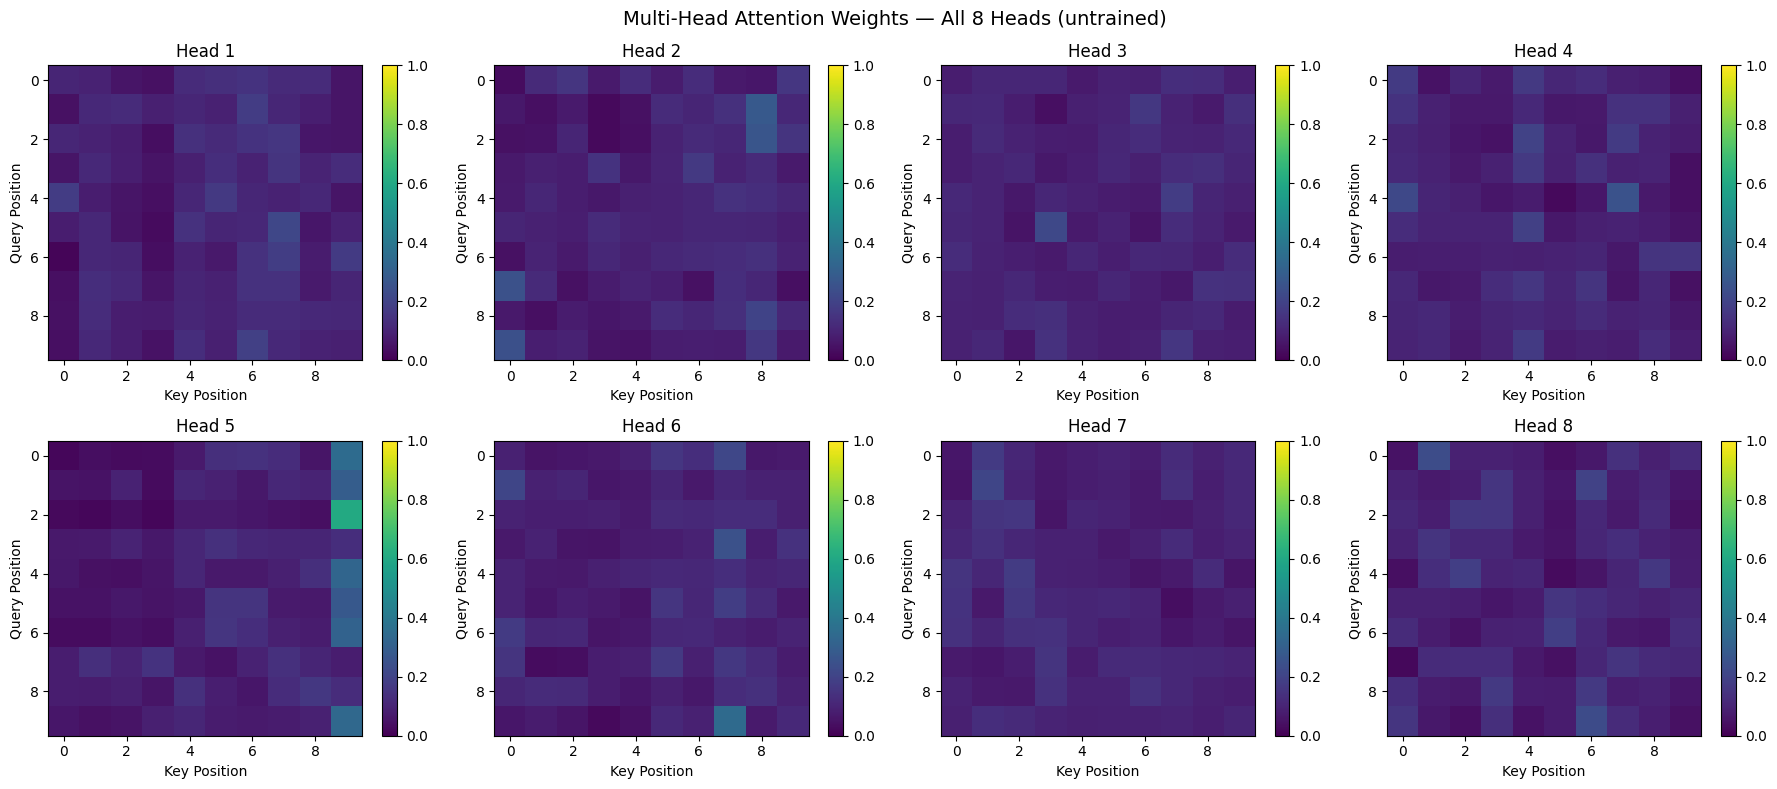

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i in range(num_heads):
    head_weights = weights[0, i].detach().numpy()
    ax = axes[i]
    im = ax.imshow(head_weights, cmap='viridis', aspect='auto', vmin=0, vmax=1)
    ax.set_title(f'Head {i+1}', fontsize=12)
    ax.set_xlabel('Key Position')
    ax.set_ylabel('Query Position')
    fig.colorbar(im, ax=ax)

plt.suptitle('Multi-Head Attention Weights — All 8 Heads (untrained)', fontsize=14)
plt.tight_layout()
plt.show()

# Sprint 3 Summary — Multi-Head Attention

---

## What This Sprint Built

An extension of single-head attention that runs $h$ independent attention heads in parallel,
each operating in a lower-dimensional subspace of the input, then combines their outputs
through concatenation and a final learned projection.

---

## Why One Head Isn't Enough

A single attention head learns one set of weight matrices $W_Q$, $W_K$, $W_V$.
This means it learns one definition of token relevance — one lens on the sequence.
Natural language contains multiple simultaneous relationship types:

| Relationship type | Example |
|---|---|
| Coreference | "she" refers to "Mary" |
| Syntactic | "gave" links subject to object |
| Semantic | "big" modifies the referent of "it" |
| Positional | adjacent tokens are structurally related |

One head must average across all of these. Multi-Head Attention runs $h$ heads in parallel,
each free to specialise in a different relationship type through independent learned projections.

---

## The Dimension Split

With $h$ heads and $d_{model}$ total dimensions:

$$d_k = d_v = \frac{d_{model}}{h}$$

Each head operates in a $d_k$-dimensional subspace. Total computation is identical to
one head at full dimension — but the model gains $h$ independent learned perspectives.

Each head $i$ computes:

$$\text{head}_i = \text{Attention}(XW_Q^{(i)},\ XW_K^{(i)},\ XW_V^{(i)})$$

$$\text{where} \quad \text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

---

## The Full Formula

$$\text{MultiHead}(X) = \text{Concat}(\text{head}_1,\ \text{head}_2,\ ...,\ \text{head}_h)\ W_O$$

| Step | Operation | Shape | What it does |
|---|---|---|---|
| Project | $X W_Q$, $X W_K$, $X W_V$ | $(B, T, d_{model})$ | Single large projection for all heads |
| Split | `.view(B, T, h, d_k).transpose(1,2)` | $(B, h, T, d_k)$ | Expose heads as a batch dimension |
| Attend | Scaled dot-product attention | $(B, h, T, d_k)$ | All heads compute in parallel |
| Merge | `.transpose(1,2).contiguous().view(B, T, d_{model})$ | $(B, T, d_{model})$ | Concatenate head outputs via reshape |
| Project | $\times\ W_O$ | $(B, T, d_{model})$ | Mix information across heads |

---

## The Shape Journey (with $d_{model}=64$, $h=8$, $T=10$, $B=2$)

```
Input X              → (2, 10, 64)
After W_Q            → (2, 10, 64)   single projection
After reshape        → (2, 10, 8, 8) split into 8 heads of d_k=8
After transpose      → (2, 8, 10, 8) heads treated as batch dimension
After attention      → (2, 8, 10, 8) 8 independent attention outputs
After transpose back → (2, 10, 8, 8)
After reshape        → (2, 10, 64)   concatenation via reshape
After W_O            → (2, 10, 64)   final mixed output
```

Output shape is identical to input shape — multi-head attention is shape-preserving.

---

## Why `.contiguous()` Is Necessary

`.transpose()` does not move data in memory — it only updates PyTorch's internal stride metadata.
`.view()` requires physically contiguous memory to safely reshape a tensor.
`.contiguous()` materialises a new tensor with memory matching the logical layout.

The pattern `transpose → contiguous → view` is mandatory whenever these three operations are chained.

---

## The Output Projection $W_O$

After concatenation, head outputs sit side by side with no cross-head interaction.
$W_O \in \mathbb{R}^{d_{model} \times d_{model}}$ is a full linear transformation — every output dimension
can see every head's output. The model learns which combinations of head findings are most useful.
Without $W_O$, heads are isolated experts. With $W_O$, they collaborate.

---

## Connecting Sprint 2 → Sprint 3

| | Sprint 2 (Single Head) | Sprint 3 (Multi-Head) |
|---|---|---|
| Projections | One set of $W_Q, W_K, W_V$ | $h$ independent sets (via reshape) |
| Attention maps | One $(T \times T)$ matrix | $h$ separate $(T \times T)$ matrices |
| Dimensions per head | $d_{model}$ | $d_{model} / h$ |
| Representational power | One lens | $h$ specialised lenses |
| Total computation | Same | Same |
| Final projection | None | $W_O$ mixes across heads |

Multi-Head Attention is not a fundamentally different operation from single-head attention.
It is the same operation, run $h$ times in parallel in lower-dimensional subspaces,
with an additional learned projection to combine the results.

---

## What The Heatmaps Show

- **8 different patterns** on the same input = 8 different learned projections seeing 8 different relationships
- **Untrained model**: differences are random — different initialisations, not meaningful specialisation
- **Trained model**: differences become semantic — heads specialise in coreference, syntax, proximity, etc.
- No one programs the specialisation — it emerges from training because diversity is more useful than redundancy

---

## Key Takeaways

- Multi-Head Attention runs $h$ attention heads in parallel, each in a $d_{model}/h$ dimensional subspace
- The total computational cost is identical to one full-dimensional attention head
- Heads are split and merged via reshape and transpose — not by looping or separate modules
- The output projection $W_O$ enables cross-head communication in the final output
- Output shape is always $(B, T, d_{model})$ — the Transformer's universal tensor format
- Specialisation emerges from training — not from explicit programming

---

*Next: Sprint 4 — The Full Transformer Block.*
*We now wrap Multi-Head Attention in Layer Normalisation, a Feed-Forward Network,*
*and residual connections to build one complete, stackable encoder block.*